In [1]:
!pip install pandas numpy seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

Using device: mps


In [11]:
model = model.to(device)

In [13]:
# generate new data
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(seed=42)
noise = rng.normal(loc=0.0, scale=1.0, size=(2))
print(noise)

m = 0.1234
c = 0.6789

X = np.arange(0, 2, 0.04)
X = np.hstack((X, noise))

Y = m * X + c

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# split = int(0.8 * len(X))
# X_train, Y_train = X[:split], Y[:split]
# X_test, Y_test = X[split:], Y[split:]

X_train_tensors = torch.from_numpy(X_train).float()
Y_train_tensors = torch.from_numpy(Y_train).float()
X_test_tensors = torch.from_numpy(X_test).float()
Y_test_tensors = torch.from_numpy(Y_test).float()

print(f"Shape of X_train is {X_train.shape} and type is {type(X_train)}")
print(
    f"Shape of X_train_tensors is {X_train_tensors.shape} and type is {type(X_train_tensors)}"
)

[ 0.30471708 -1.03998411]
Shape of X_train is (41,) and type is <class 'numpy.ndarray'>
Shape of X_train_tensors is torch.Size([41]) and type is <class 'torch.Tensor'>


In [14]:
def plot_data(
    X_train=X_train_tensors,
    Y_train=Y_train_tensors,
    X_test=X_test_tensors,
    Y_test=Y_test_tensors,
    prediction = None
):
    plt.scatter(X_train,Y_train,c='b',label='Training data')
    plt.scatter(X_test,Y_test,c='r',label='Testing data')
    if prediction is not None:
        plt.plot(X_test, prediction, c='g', label='Predictions')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("X vs Y")
    plt.legend()
    plt.show()
        
        


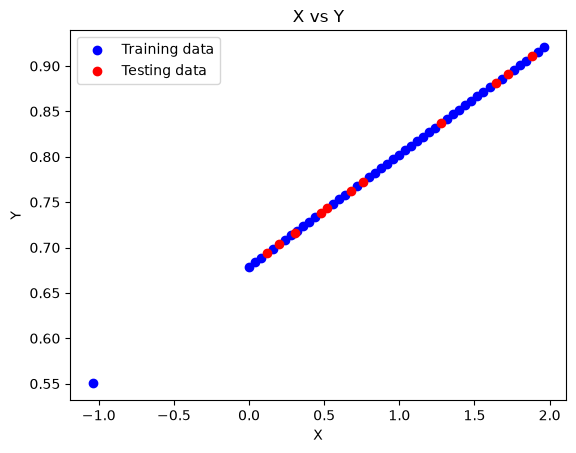

In [15]:
plot_data(X_train_tensors, Y_train_tensors, X_test_tensors, Y_test_tensors)

In [16]:
from torch import nn


class myFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(1, requires_grad=True, dtype=torch.float32)
        )
        self.bias = nn.Parameter(
            torch.randn(1, requires_grad=True, dtype=torch.float32)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [17]:
# creating our first model


model = myFirstNeuralNetwork()
print(model.state_dict())

OrderedDict({'weights': tensor([1.7158]), 'bias': tensor([-1.1059])})


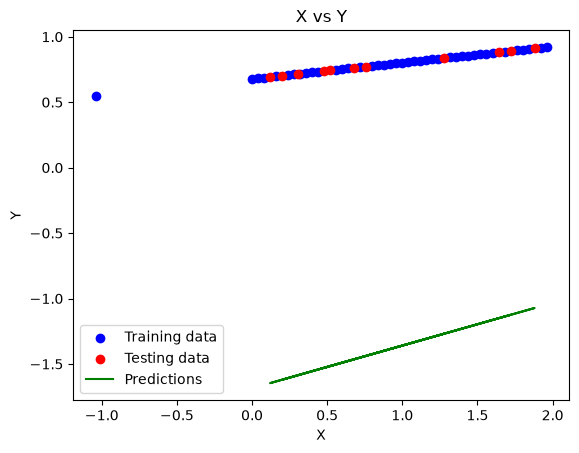

In [ ]:
with torch.inference_mode():
    Y_preds = model(X_test_tensors)


plot_data(prediction=Y_preds)

In [18]:
#set up loss fuction and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    params= model.parameters(),
    lr = 0.1
)

In [19]:
# set up the training loop

epochs = 500
train_loss_list = []
test_loss_list = []

model.to(device)
X_train_tensors, Y_train_tensors = X_train_tensors.to(device), Y_train_tensors.to(device)
X_test_tensors, Y_test_tensors = X_test_tensors.to(device), Y_test_tensors.to(device)

for epoch in range(epochs):
    model.train()
    train_preds = model(X_train_tensors)
    train_loss = loss_fn(train_preds, Y_train_tensors)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_preds = model(X_test_tensors)
        test_loss = loss_fn(test_preds, Y_test_tensors)

    train_loss_list.append(train_loss.detach().cpu().numpy())
    test_loss_list.append(test_loss.detach().cpu().numpy())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch: {epoch+1} | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}"
        )

Epoch: 50 | Train Loss: 0.0225 | Test Loss: 0.0210
Epoch: 100 | Train Loss: 0.0004 | Test Loss: 0.0004
Epoch: 150 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 200 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 250 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 300 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 350 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 400 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 450 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 500 | Train Loss: 0.0000 | Test Loss: 0.0000


In [20]:
train_loss_list

[array(1.1222073, dtype=float32),
 array(1.0327964, dtype=float32),
 array(0.9525567, dtype=float32),
 array(0.87923914, dtype=float32),
 array(0.8117958, dtype=float32),
 array(0.749603, dtype=float32),
 array(0.6922009, dtype=float32),
 array(0.63920313, dtype=float32),
 array(0.590266, dtype=float32),
 array(0.5450765, dtype=float32),
 array(0.5033468, dtype=float32),
 array(0.464812, dtype=float32),
 array(0.42922747, dtype=float32),
 array(0.39636704, dtype=float32),
 array(0.36602238, dtype=float32),
 array(0.33800083, dtype=float32),
 array(0.3121245, dtype=float32),
 array(0.2882292, dtype=float32),
 array(0.26616323, dtype=float32),
 array(0.24578658, dtype=float32),
 array(0.22696988, dtype=float32),
 array(0.20959374, dtype=float32),
 array(0.1935479, dtype=float32),
 array(0.17873046, dtype=float32),
 array(0.16504739, dtype=float32),
 array(0.15241186, dtype=float32),
 array(0.14074366, dtype=float32),
 array(0.12996873, dtype=float32),
 array(0.12001873, dtype=float32),
 

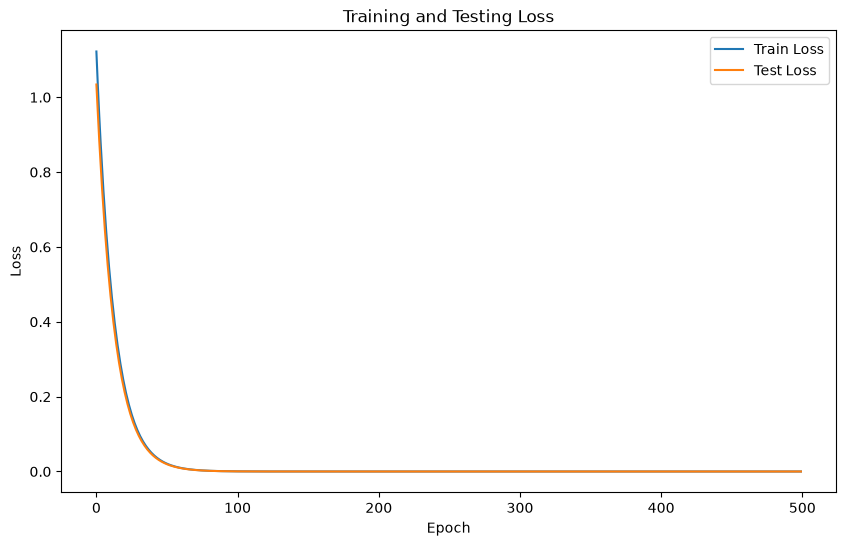

In [21]:
# plot the loss curve

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_loss_list, label="Train Loss")
plt.plot(range(epochs), test_loss_list, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss")
plt.legend()
plt.show()

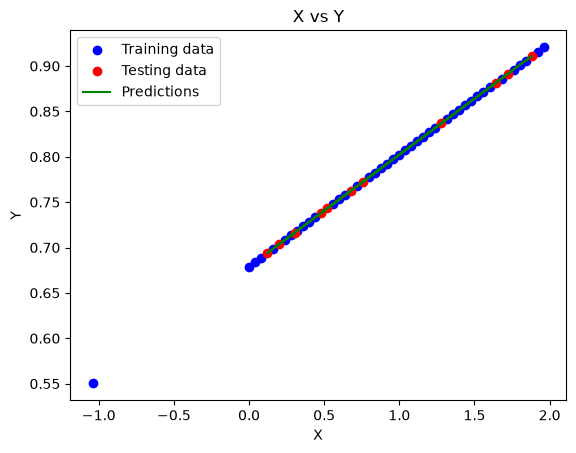

In [23]:
with torch.inference_mode():
    Y_preds = model(X_test_tensors)

Y_preds = Y_preds.cpu()

plot_data(prediction=Y_preds)